# Tutorial 8: Generator and Power Electronics Loss Models (``module_rotor_simulation``)

This optional advanced tutorial demonstrates how to use the power-conversion modes in ``RotorSimulation``.

The turbine rotor and drivetrain dynamics are always simulated using the same underlying turbine model. After the rotor dynamics are solved, the selected power-conversion model is used to calculate electrical power, losses, AC-side power, and battery-side power.

The four supported power-conversion modes are:

1. **``simple``**  
   Built-in generator electrical model using ``Kt`` and ``Rw``.

2. **``simple_with_pe_loss``**  
   Built-in generator model plus a user-supplied power electronics loss model.

3. **``generator_loss_model``**  
   User-supplied generator loss model used to compute AC-side power from mechanical power.

4. **``generator_and_pe_loss_models``**  
   User-supplied generator and power electronics loss models used to compute AC-side and battery-side power.

## Notes for new users

- This is an advanced tutorial. New users should complete the rotor simulation tutorial first.
- In ``generator_loss_model`` and ``generator_and_pe_loss_models``, ``Pelec`` is treated as AC-side power and is equal to ``Pac``.
- In ``simple`` and ``simple_with_pe_loss``, ``Pelec`` comes from the built-in generator electrical model.
- If power electronics losses are included, battery-side power is available as ``Pbat``. For battery-charging studies with PE losses, ``Pbat`` is usually the most relevant delivered-power quantity.
- The optional loss models are applied after the rotor/drivetrain dynamics are solved. They affect ``Pac``, ``Pbat``, and loss terms, but they do not feed back into rotor speed or generator torque.
- The example loss equations in this tutorial are illustrative. Users should replace them with loss models appropriate for their generator and power electronics hardware.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib3

from vital.module_tidal import process_tidal_data
from vital.module_rotor import RotorData
from vital.module_rotor_simulation import RotorSimulation

# Suppress warnings caused by NOAA requests using verify=False internally.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

## 1. Load tidal resource data

First, load tidal current data using the same basic NOAA workflow used in previous tutorials.

This tutorial uses NOAA data directly. If NOAA access is unavailable, use the local-file workflow from the tidal-data tutorial or configure the documentation build so notebooks are not executed.

Data source: NOAA
Station name: Port Mackenzie, South of
Mooring distance: 31.10 m
Cable length: 3970.22 m
Number of time points: 336


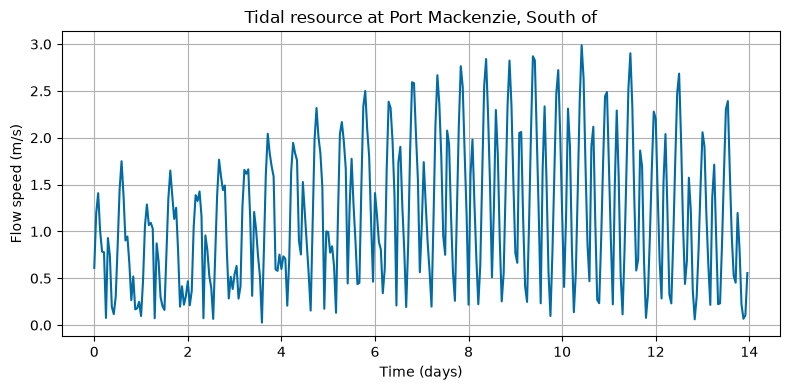

In [2]:
station = "COI0303"
startdate = "2021-09-01"

range_hrs = 2 * 7 * 24
time_step_s = 3600
city_data_file = "../data/AlaskaCityLatLong.txt"

tidal = process_tidal_data(
    station=station,
    startdate=startdate,
    range_hrs=range_hrs,
    time_step_s=time_step_s,
    city_data_file=city_data_file,
)

print(f"Data source: {tidal.source}")
print(f"Station name: {tidal.station_name}")
print(f"Mooring distance: {tidal.mooring_distance:.2f} m")
print(f"Cable length: {tidal.cable_length:.2f} m")
print(f"Number of time points: {len(tidal.times)}")

time_days = tidal.times / (3600 * 24)

plt.figure(figsize=(8, 4))
plt.plot(time_days, tidal.flow_speeds)
plt.xlabel("Time (days)")
plt.ylabel("Flow speed (m/s)")
plt.title(f"Tidal resource at {tidal.station_name}")
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Load rotor performance data

Next, load the rotor performance data.

The rotor file provides ``TSR``, ``Ct``, and ``Cq``. VITAL computes the power coefficient internally as:

$$
C_p = TSR \cdot C_q
$$

The resulting rotor object provides coefficient functions used by the simulation. See the rotor-data tutorial for details on interpolation, extrapolation, and optional ``Cpmin`` data.

In [3]:
rotor_performance_file = "../data/Sitkana_rotor_data_blade_2.txt"
rotor = RotorData(rotor_performance_file)

print(f"Optimal Cp: {rotor.CpOpt:.4f}")
print(f"Optimal TSR: {rotor.TSROpt:.4f}")
print(f"Estimated TSRmax: {rotor.TSRmax:.4f}")
print(f"Measured TSR range: {rotor.tsr.min():.4f} to {rotor.tsr.max():.4f}")

Optimal Cp: 0.2119
Optimal TSR: 0.7648
Estimated TSRmax: 1.7084
Measured TSR range: 0.0526 to 1.7015


## 3. Define a base turbine configuration

Set up a base configuration that will be reused for all four power-conversion modes.

The ``number_of_turbines`` entry is included for consistency with other tutorials, although ``RotorSimulation`` evaluates a single-turbine time series.

The ``power_model`` entry is intentionally not included in this base configuration. It is added separately for each power-conversion mode in the next section.

In [4]:
base_config = {
    # Turbine geometry and ratings
    "Radius": 0.5,                    # Rotor radius (m)
    "Prated": 1000.0,                 # Rated electrical power (W)
    "Trated": 15.0,                   # Rated generator torque (N m)
    "dHub": 2.0,                      # Hub depth (m)

    # Included for consistency with other tutorials.
    # RotorSimulation itself evaluates a single-turbine time series.
    "number_of_turbines": 2,

    # Site/time inputs
    "dMoor": tidal.mooring_distance,  # Mooring depth/distance (m)
    "Uinf": tidal.flow_speeds,        # Surface/current speed time series (m/s)
    "t": tidal.times,                 # Time vector (s)

    # Rotor performance functions
    "CpFunc": rotor.get_cp,
    "CqFunc": rotor.get_cq,
    "CtFunc": rotor.get_ct,
    "CpOpt": rotor.CpOpt,
    "TSROpt": rotor.TSROpt,
    "TSRmax": rotor.TSRmax,

    # Drivetrain and generator parameters
    "Ng": 20,                         # Gear ratio
    "Kt": 1.5,                        # Generator torque constant
    "Rw": 1.0,                        # Generator winding resistance
    "J_d": 1.0,                       # Drivetrain inertia
    "B_d": 0.5,                       # Drivetrain damping/friction
    "J_r": 1.0,                       # Rotor inertia
}

## 4. Define example loss models

In the loss-model modes, users provide loss equations as Python callables of the form

```python
loss_model(omega_g, tau)
```

where:

- ``omega_g`` is generator-side angular speed in rad/s
- ``tau`` is generator torque in N m

The callable should return loss power in watts.

In this example, generator and power electronics losses are represented using simple algebraic equations. These are illustrative example models and should be replaced with validated loss models for a specific generator and power electronics system.

The implementation clips user-supplied loss values to be nonnegative before computing ``Pac`` and ``Pbat``.

In [5]:
def generator_loss_model(omega_g, tau):
    """
    Example generator loss model.

    Parameters
    ----------
    omega_g : float or np.ndarray
        Generator-side angular speed (rad/s).
    tau : float or np.ndarray
        Generator torque (N m).

    Returns
    -------
    float or np.ndarray
        Generator loss power (W).
    """
    return 0.137 * np.abs(omega_g) + 3.118 * tau**2


def pe_loss_model(omega_g, tau):
    """
    Example power electronics loss model.

    Parameters
    ----------
    omega_g : float or np.ndarray
        Generator-side angular speed (rad/s).
    tau : float or np.ndarray
        Generator torque (N m).

    Returns
    -------
    float or np.ndarray
        Power electronics loss power (W).
    """
    return 5.204 + 0.2896 * np.abs(omega_g) + 0.3559 * np.abs(tau)

## 5. Run the four supported power-conversion modes

Next, run the same rotor/turbine configuration using each supported ``power_model``.

The helper function below copies ``base_config``, applies the mode-specific updates, runs ``RotorSimulation``, and returns the simulation results.

In [6]:
def run_rotor_simulation(config_updates, label):
    """
    Create a simulation configuration, run RotorSimulation, and return results.

    Parameters
    ----------
    config_updates : dict
        Dictionary of settings to update from base_config.
    label : str
        Label printed to identify the simulation mode.

    Returns
    -------
    dict
        Simulation results from RotorSimulation.get_results().
    """
    config = base_config.copy()
    config.update(config_updates)

    print(f"Running mode: {label}")

    sim = RotorSimulation(config)
    sim.simulate()
    results = sim.get_results()

    print(f"  Complete.")
    print(f"    Mean Pelec:     {np.mean(results['Pelec']) / 1000:.3f} kW")
    print(f"    Mean Pac:       {np.mean(results['Pac']) / 1000:.3f} kW")
    print(f"    Mean Pbat:      {np.mean(results['Pbat']) / 1000:.3f} kW")
    print(f"    Mean Pgen_loss: {np.mean(results['Pgen_loss']) / 1000:.3f} kW")
    print(f"    Mean Ppe_loss:  {np.mean(results['Ppe_loss']) / 1000:.3f} kW")
    print()

    return results


# Mode 1: simple
# Built-in generator electrical model using Kt and Rw.
res_simple = run_rotor_simulation(
    config_updates={
        "power_model": "simple",
    },
    label="simple",
)


# Mode 2: simple_with_pe_loss
# Built-in generator model plus user-supplied power electronics loss model.
res_simple_pe = run_rotor_simulation(
    config_updates={
        "power_model": "simple_with_pe_loss",
        "pe_loss_model": pe_loss_model,
    },
    label="simple_with_pe_loss",
)


# Mode 3: generator_loss_model
# User-supplied generator loss model. No PE loss model is applied.
res_gen_loss = run_rotor_simulation(
    config_updates={
        "power_model": "generator_loss_model",
        "generator_loss_model": generator_loss_model,
    },
    label="generator_loss_model",
)


# Mode 4: generator_and_pe_loss_models
# User-supplied generator loss model plus user-supplied PE loss model.
res_gen_pe = run_rotor_simulation(
    config_updates={
        "power_model": "generator_and_pe_loss_models",
        "generator_loss_model": generator_loss_model,
        "pe_loss_model": pe_loss_model,
    },
    label="generator_and_pe_loss_models",
)

Running mode: simple
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  Complete.
    Mean Pelec:     0.037 kW
    Mean Pac:       0.037 kW
    Mean Pbat:      0.037 kW
    Mean Pgen_loss: 0.000 kW
    Mean Ppe_loss:  0.000 kW

Running mode: simple_with_pe_loss
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  Complete.
    Mean Pelec:     0.037 kW
    Mean Pac:       0.037 kW
    Mean Pbat:      0.030 kW
    Mean Pgen_loss: 0.000 kW
    Mean Ppe_loss:  0.010 kW

Running mode: generator_loss_model
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  Complete.
    Mean Pelec:     0.023 kW
    Mean Pac:       0.023 kW
    Mean Pbat:      0.023 kW
    Mean Pgen_loss: 0.015 kW
    Mean Ppe_loss:  0.000 kW

Running mode: generator_and_pe_loss_models
Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
  Complete.
    Mean Pelec:     0.023 kW
    Mean Pac:       0.023 kW
    Mean Pbat:      0.017 kW
    Mean Pgen_loss: 0.015 kW
    Mean Ppe_loss:  0.010 kW



## 6. Compare power-conversion modes by application

The four supported power-conversion modes can be interpreted in terms of the output quantity of interest:

- **Grid connection or AC-side analysis**: modes focused on AC-side electrical output, ``Pac``.
- **Battery charging or DC-side analysis**: modes that include power-electronics losses and report battery-side power, ``Pbat``.

The following comparisons are organized around these output quantities.

### Grid connection or AC-side comparison

For grid-connected applications, the primary quantity of interest is often the AC-side electrical output power, ``Pac``.

The comparison below shows the default simple generator model and the optional ``generator_loss_model`` formulation.

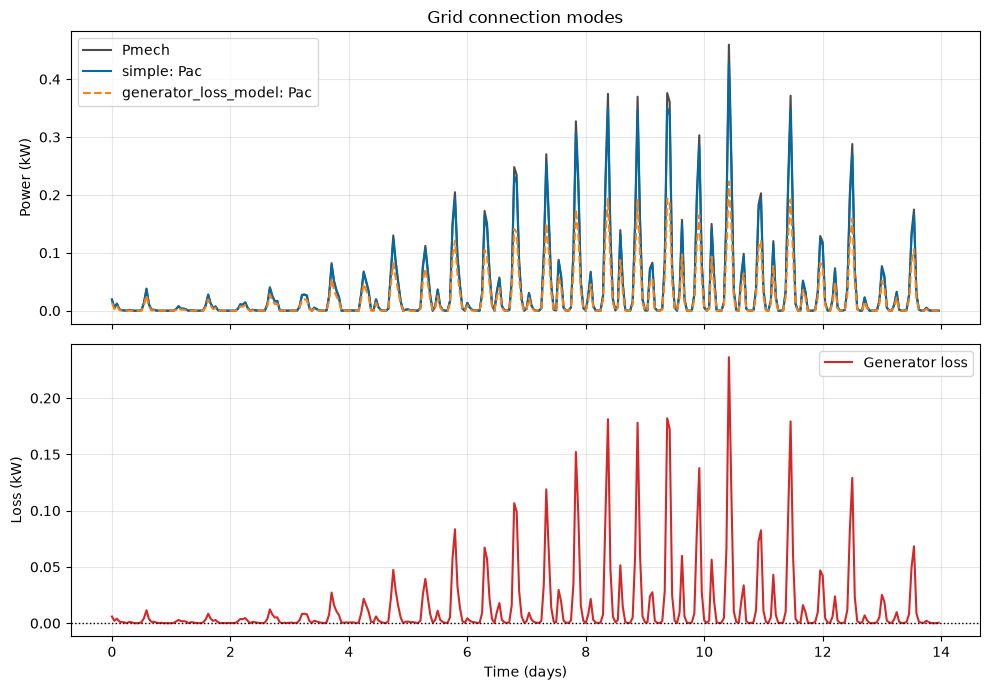

In [7]:
time_days = res_simple["t"] / (3600 * 24)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# AC-side power
ax[0].plot(
    time_days,
    res_simple["Pmech"] / 1000,
    label="Pmech",
    color="k",
    alpha=0.7,
)
ax[0].plot(
    time_days,
    res_simple["Pac"] / 1000,
    label="simple: Pac",
    linestyle="-",
)
ax[0].plot(
    time_days,
    res_gen_loss["Pac"] / 1000,
    label="generator_loss_model: Pac",
    linestyle="--",
)
ax[0].set_ylabel("Power (kW)")
ax[0].set_title("Grid connection modes")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Generator loss
ax[1].plot(
    time_days,
    res_gen_loss["Pgen_loss"] / 1000,
    label="Generator loss",
    color="tab:red",
)
ax[1].axhline(0.0, color="k", linestyle=":", linewidth=1)
ax[1].set_ylabel("Loss (kW)")
ax[1].set_xlabel("Time (days)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Battery charging or DC-side comparison

For battery-charging applications, the AC-side power, battery-side power, generator loss, and power electronics loss can be compared separately.

In this comparison, ``Pbat`` represents the battery-side power after power-electronics losses are applied. This makes it easier to see how the optional generator loss model changes the overall power-conversion pathway.

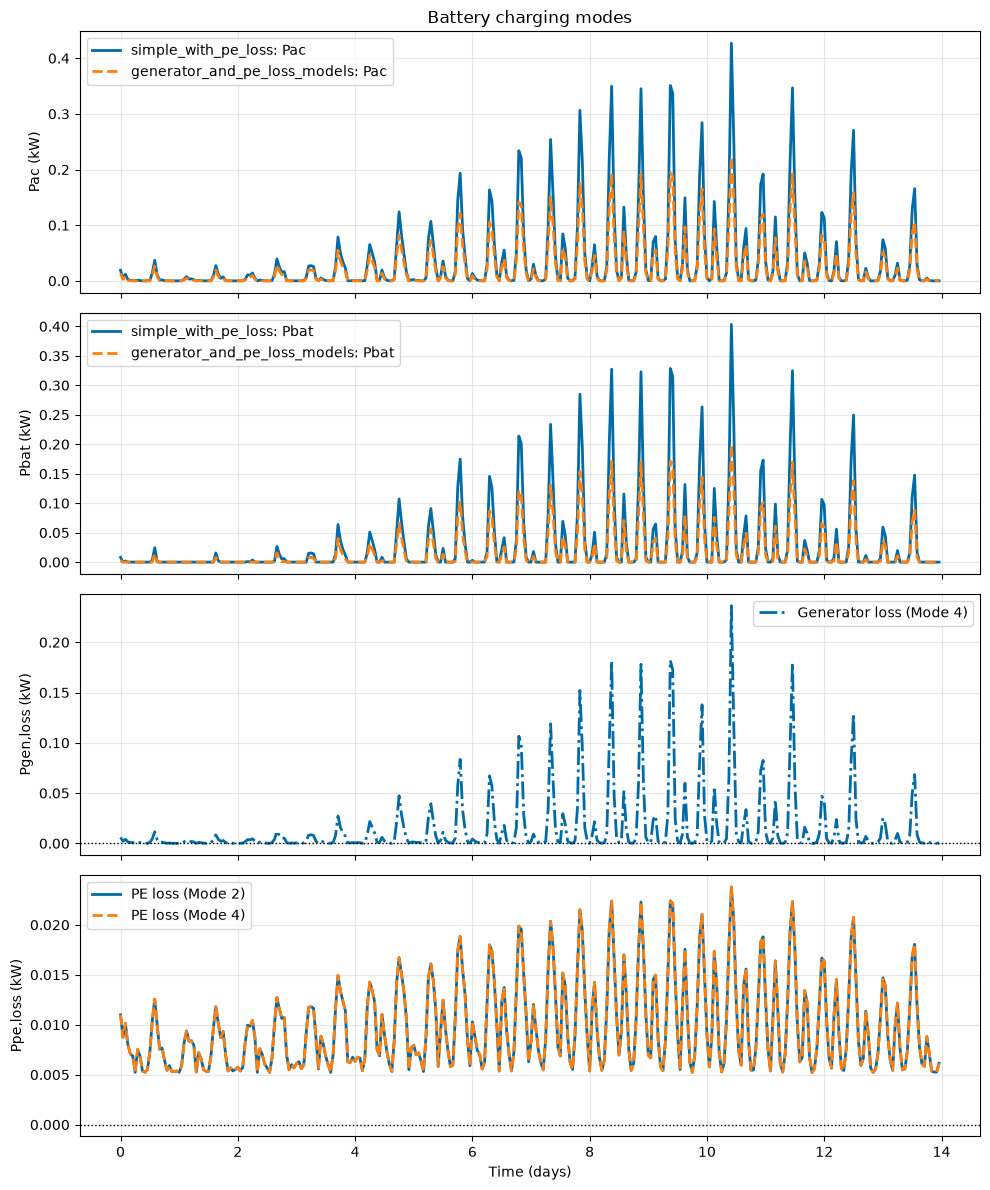

In [8]:
time_days = res_simple_pe["t"] / (3600 * 24)

fig, ax = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

lw = 2

# AC-side power
ax[0].plot(
    time_days,
    res_simple_pe["Pac"] / 1000,
    linestyle="-",
    linewidth=lw,
    label="simple_with_pe_loss: Pac",
)
ax[0].plot(
    time_days,
    res_gen_pe["Pac"] / 1000,
    linestyle="--",
    linewidth=lw,
    label="generator_and_pe_loss_models: Pac",
)
ax[0].set_ylabel("Pac (kW)")
ax[0].set_title("Battery charging modes")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Battery-side power
ax[1].plot(
    time_days,
    res_simple_pe["Pbat"] / 1000,
    linestyle="-",
    linewidth=lw,
    label="simple_with_pe_loss: Pbat",
)
ax[1].plot(
    time_days,
    res_gen_pe["Pbat"] / 1000,
    linestyle="--",
    linewidth=lw,
    label="generator_and_pe_loss_models: Pbat",
)
ax[1].set_ylabel("Pbat (kW)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# Generator loss
ax[2].plot(
    time_days,
    res_gen_pe["Pgen_loss"] / 1000,
    linestyle="-.",
    linewidth=lw,
    label="Generator loss (Mode 4)",
)
ax[2].axhline(0.0, color="k", linestyle=":", linewidth=1)
ax[2].set_ylabel("Pgen,loss (kW)")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

# PE loss
ax[3].plot(
    time_days,
    res_simple_pe["Ppe_loss"] / 1000,
    linestyle="-",
    linewidth=lw,
    label="PE loss (Mode 2)",
)
ax[3].plot(
    time_days,
    res_gen_pe["Ppe_loss"] / 1000,
    linestyle="--",
    linewidth=lw,
    label="PE loss (Mode 4)",
)
ax[3].axhline(0.0, color="k", linestyle=":", linewidth=1)
ax[3].set_ylabel("Ppe,loss (kW)")
ax[3].set_xlabel("Time (days)")
ax[3].legend()
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summarize average power by mode

The plots above show the time-varying behavior. It is also useful to compare average power and loss values for each mode.

The table below summarizes:

- mean mechanical power, ``Pmech``
- mean primary electrical output, ``Pelec``
- mean AC-side power, ``Pac``
- mean battery-side power, ``Pbat``
- mean generator loss, ``Pgen_loss``
- mean power-electronics loss, ``Ppe_loss``

All values are reported in kW.

In [9]:
def summarize_mode(name, results):
    """
    Return mean power and loss quantities for one simulation mode in kW.
    """
    return {
        "mode": name,
        "Pmech_kW": np.mean(results["Pmech"]) / 1000,
        "Pelec_kW": np.mean(results["Pelec"]) / 1000,
        "Pac_kW": np.mean(results["Pac"]) / 1000,
        "Pbat_kW": np.mean(results["Pbat"]) / 1000,
        "Pgen_loss_kW": np.mean(results["Pgen_loss"]) / 1000,
        "Ppe_loss_kW": np.mean(results["Ppe_loss"]) / 1000,
    }


summary_rows = [
    summarize_mode("simple", res_simple),
    summarize_mode("simple_with_pe_loss", res_simple_pe),
    summarize_mode("generator_loss_model", res_gen_loss),
    summarize_mode("generator_and_pe_loss_models", res_gen_pe),
]

header = (
    f"{'Mode':<38}"
    f"{'Pmech':>10}"
    f"{'Pelec':>10}"
    f"{'Pac':>10}"
    f"{'Pbat':>10}"
    f"{'Pgen_loss':>14}"
    f"{'Ppe_loss':>12}"
)

print(header)
print("-" * len(header))

for row in summary_rows:
    print(
        f"{row['mode']:<38}"
        f"{row['Pmech_kW']:>10.3f}"
        f"{row['Pelec_kW']:>10.3f}"
        f"{row['Pac_kW']:>10.3f}"
        f"{row['Pbat_kW']:>10.3f}"
        f"{row['Pgen_loss_kW']:>14.3f}"
        f"{row['Ppe_loss_kW']:>12.3f}"
    )

Mode                                       Pmech     Pelec       Pac      Pbat     Pgen_loss    Ppe_loss
--------------------------------------------------------------------------------------------------------
simple                                     0.039     0.037     0.037     0.037         0.000       0.000
simple_with_pe_loss                        0.039     0.037     0.037     0.030         0.000       0.010
generator_loss_model                       0.039     0.023     0.023     0.023         0.015       0.000
generator_and_pe_loss_models               0.039     0.023     0.023     0.017         0.015       0.010


## 8. Interpreting the results

The four modes represent different levels of power-conversion detail:

- ``simple``: uses the built-in generator model. No generator-loss model or PE-loss model is applied.
- ``simple_with_pe_loss``: starts from the built-in generator model, then subtracts PE losses to compute ``Pbat``.
- ``generator_loss_model``: subtracts a user-supplied generator loss from mechanical power to compute ``Pac``.
- ``generator_and_pe_loss_models``: subtracts both generator losses and PE losses to compute battery-side power.

For grid-connected or AC-side studies, ``Pac`` is usually the most relevant output.

For battery-charging studies with power-electronics losses, ``Pbat`` is usually the most relevant delivered-power output.

## 9. Summary

This tutorial demonstrated four power-conversion modes in ``RotorSimulation``:

- ``simple``
- ``simple_with_pe_loss``
- ``generator_loss_model``
- ``generator_and_pe_loss_models``

The main outputs are:

- ``Pmech``: mechanical power at the generator side
- ``Pelec``: primary electrical output used for compatibility with other VITAL workflows
- ``Pac``: AC-side electrical power
- ``Pbat``: battery-side power; when PE losses are included, this is ``Pac`` minus PE losses
- ``Pgen_loss``: generator loss
- ``Ppe_loss``: power-electronics loss

The example loss equations in this tutorial are illustrative. Users should replace them with validated generator and power-electronics loss models for their own hardware.